# AI Travel Planner & Recommender System
**Course:** Introduction to AI - Semester 2, 2025-2026  
**University:** Ho Chi Minh City University of Technology, VNU-HCM  
**Instructor:** Dr. Truong Vinh Lan  

---

## This Notebook Includes:
1. Install Libraries & Download Data
2. Load & Clean Data
3. EDA (Exploratory Data Analysis)
4. Feature Engineering
5. Export Features (.npy / .csv)

**Note:** Go to Runtime → Run All to execute the entire notebook.

## 0. Setup - Install Libraries & Clone Repo

In [1]:
# Cai dat thu vien can thiet
!pip install opendatasets pandas numpy matplotlib seaborn scikit-learn -q

In [2]:
# Clone repository
import os
if not os.path.exists('Introduction-AI-Assignment'):
    !git clone https://github.com/HieNguyen08/Introduction-AI-Assignment.git
    os.chdir('Introduction-AI-Assignment')
else:
    os.chdir('Introduction-AI-Assignment')

print('Working directory:', os.getcwd())

Cloning into 'Introduction-AI-Assignment'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 61 (delta 18), reused 51 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 351.74 KiB | 1.84 MiB/s, done.
Resolving deltas: 100% (18/18), done.
Working directory: /content/Introduction-AI-Assignment


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

print('Libraries loaded.')

Libraries loaded.


In [4]:
# Import module data_pipeline
import sys
sys.path.insert(0, '.')

from modules.data_pipeline import (
    download_all_datasets, ensure_dirs,
    load_vietnam_weather, load_hotel_reviews, load_travel_ratings,
    load_traveler_trips, load_world_cities,
    clean_vietnam_weather, clean_hotel_reviews, clean_travel_ratings,
    clean_traveler_trips, clean_world_cities,
    build_distance_matrix, build_cost_matrix, build_travel_time_matrix,
    build_weather_probability_table, build_places_dataframe,
    save_cleaned, save_features, save_feature_csv,
    VN_TOURIST_PLACES, VN_PROVINCE_COORDS,
    RAW_DIR, CLEANED_DIR, PROCESSED_DIR, FEATURES_DIR,
    haversine
)

ensure_dirs()
print('Module data_pipeline imported.')

Module data_pipeline imported.


---
## 1. Download Datasets from Kaggle

All datasets are downloaded directly from **public Kaggle sources** into the Colab runtime environment.  

| # | Dataset | Kaggle URL | AI Component |
|---|---------|-----------|--------------|
| 1 | Vietnam Weather Data | https://www.kaggle.com/datasets/vanviethieuanh/vietnam-weather-data | (C) + (D) |
| 2 | 515K Hotel Reviews Europe | https://www.kaggle.com/datasets/jiashenliu/515k-hotel-reviews-data-in-europe | (E) |
| 3 | Travel Review Ratings (UCI) | https://www.kaggle.com/datasets/ishbhms/travel-review-ratings | (E) |
| 4 | Traveler Trip Data | https://www.kaggle.com/datasets/rkiattisak/traveler-trip-data | (B) |
| 5 | Worldwide Travel Cities | https://www.kaggle.com/datasets/furkanima/worldwide-travel-cities-ratings-and-climate | (E) |

In [5]:
import os, json

# ----------------------------------------------------------------
# Kaggle authentication — writes ~/.kaggle/kaggle.json
# Get your token at: https://www.kaggle.com/settings -> API -> Create New Token
# ----------------------------------------------------------------
KAGGLE_USERNAME = 'HieuNguyen'          # <-- your Kaggle username
KAGGLE_KEY      = 'KGAT_f82c3407a5d7881d0e09f52ac01314f8'  # <-- paste your API key here

kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
kaggle_json_path = os.path.join(kaggle_dir, 'kaggle.json')
with open(kaggle_json_path, 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
os.chmod(kaggle_json_path, 0o600)

print('Kaggle credentials saved to:', kaggle_json_path)

Kaggle credentials saved to: /root/.kaggle/kaggle.json


In [6]:
# Download all datasets using Kaggle CLI (no interactive prompts)
# Data is saved directly to data/raw/ in the Colab runtime (not cloud storage)
download_all_datasets(use_opendatasets=False)

Dùng Kaggle CLI: kaggle datasets download -d <dataset_id>
  kaggle datasets download -d vanviethieuanh/vietnam-weather-data -p "/content/Introduction-AI-Assignment/data/raw" --unzip
  kaggle datasets download -d jiashenliu/515k-hotel-reviews-data-in-europe -p "/content/Introduction-AI-Assignment/data/raw" --unzip
  kaggle datasets download -d ishbhms/travel-review-ratings -p "/content/Introduction-AI-Assignment/data/raw" --unzip
  kaggle datasets download -d rkiattisak/traveler-trip-data -p "/content/Introduction-AI-Assignment/data/raw" --unzip
  kaggle datasets download -d furkanima/worldwide-travel-cities-ratings-and-climate -p "/content/Introduction-AI-Assignment/data/raw" --unzip

[DONE] Tất cả datasets đã được tải về: /content/Introduction-AI-Assignment/data/raw


In [7]:
# Kiem tra file da tai
for root, dirs, files in os.walk(RAW_DIR):
    for f in files:
        fpath = os.path.join(root, f)
        size_mb = os.path.getsize(fpath) / (1024*1024)
        print(f'  {os.path.relpath(fpath, RAW_DIR):60s} {size_mb:8.2f} MB')

  google_review_ratings.csv                                        0.61 MB
  Worldwide Travel Cities Dataset (Ratings and Climate).csv        0.46 MB
  Hotel_Reviews.csv                                              227.12 MB
  weather.csv                                                      8.13 MB
  Travel details dataset.csv                                       0.01 MB
  .gitkeep                                                         0.00 MB


---
## 2. Load & Clean Data

### 2.1 Vietnam Weather Data (181K records, 40 provinces, 2009-2021)
**Serves:** (C) IF-THEN Rule System + (D) Bayesian Network

In [8]:
# Load & Clean
df_weather_raw = load_vietnam_weather()
print('\nRaw shape:', df_weather_raw.shape)
print('\nCot:', list(df_weather_raw.columns))
df_weather_raw.head()

[LOAD] Vietnam Weather: 181,960 rows, 10 cols — /content/Introduction-AI-Assignment/data/raw/weather.csv

Raw shape: (181960, 10)

Cot: ['province', 'max', 'min', 'wind', 'wind_d', 'rain', 'humidi', 'cloud', 'pressure', 'date']


,province,max,min,wind,wind_d,rain,humidi,cloud,pressure,date
0,Bac Lieu,27,22,17,NNE,6.9,90,71,1010,2009-01-01
1,Bac Lieu,31,25,20,ENE,0.0,64,24,1010,2010-01-01
2,Bac Lieu,29,24,14,E,0.0,75,45,1008,2011-01-01
3,Bac Lieu,30,24,30,E,0.0,79,52,1012,2012-01-01
4,Bac Lieu,31,25,20,ENE,0.0,70,24,1010,2013-01-01


In [9]:
df_weather = clean_vietnam_weather(df_weather_raw)
save_cleaned(df_weather, 'vietnam_weather')

print('\nCleaned shape:', df_weather.shape)
print('\nMissing values:')
print(df_weather.isnull().sum())
print('\nData types:')
print(df_weather.dtypes)
df_weather.head()

[CLEAN] Vietnam Weather: 181,960 rows, 19 cols
[SAVE] /content/Introduction-AI-Assignment/data/cleaned/vietnam_weather.csv (181,960 rows)

Cleaned shape: (181960, 19)

Missing values:
province            0
temp_max            0
temp_min            0
wind_speed          0
wind_dir            0
rain_mm             0
humidity            0
cloud_cover         0
pressure            0
date                0
year                0
month               0
day                 0
season              0
is_rainy            0
rain_level          0
is_humid            0
is_hot              0
outdoor_suitable    0
dtype: int64

Data types:
province                    object
temp_max                     int64
temp_min                     int64
wind_speed                   int64
wind_dir                    object
rain_mm                    float64
humidity                     int64
cloud_cover                  int64
pressure                     int64
date                datetime64[ns]
year                  

,province,temp_max,temp_min,wind_speed,wind_dir,rain_mm,humidity,cloud_cover,pressure,date,year,month,day,season,is_rainy,rain_level,is_humid,is_hot,outdoor_suitable
0,Bac Lieu,27,22,17,NNE,6.9,90,71,1010,2009-01-01,2009,1,1,winter,1,moderate,1,0,0
1,Bac Lieu,31,25,20,ENE,0.0,64,24,1010,2010-01-01,2010,1,1,winter,0,none,0,0,1
2,Bac Lieu,29,24,14,E,0.0,75,45,1008,2011-01-01,2011,1,1,winter,0,none,0,0,1
3,Bac Lieu,30,24,30,E,0.0,79,52,1012,2012-01-01,2012,1,1,winter,0,none,0,0,1
4,Bac Lieu,31,25,20,ENE,0.0,70,24,1010,2013-01-01,2013,1,1,winter,0,none,0,0,1


In [10]:
df_weather.describe()

,temp_max,temp_min,wind_speed,rain_mm,humidity,cloud_cover,pressure,date,year,month,day,is_rainy,is_humid,is_hot,outdoor_suitable
count,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000,181960.000000
mean,29.837277,23.277874,11.038657,6.567130,77.083068,41.721268,1010.229127,2015-03-26 06:37:35.440755968,2014.741482,6.407342,15.692680,0.567883,0.384991,0.066234,0.651995
min,4.000000,2.000000,1.000000,0.000000,23.000000,0.000000,988.000000,2009-01-01 00:00:00,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,21.000000,7.000000,0.100000,71.000000,23.000000,1008.000000,2012-02-12 00:00:00,2012.000000,3.000000,8.000000,0.000000,0.000000,0.000000,0.000000
50%,31.000000,24.000000,10.000000,1.800000,78.000000,38.000000,1010.000000,2015-03-26 00:00:00,2015.000000,6.000000,16.000000,1.000000,0.000000,0.000000,1.000000
75%,33.000000,26.000000,14.000000,7.500000,83.000000,58.000000,1012.000000,2018-05-07 00:00:00,2018.000000,9.000000,23.000000,1.000000,1.000000,0.000000,1.000000
max,46.000000,32.000000,54.000000,596.400000,100.000000,100.000000,1038.000000,2021-06-18 00:00:00,2021.000000,12.000000,31.000000,1.000000,1.000000,1.000000,1.000000
std,4.571345,3.945381,5.311807,13.602055,9.288553,23.875067,4.635714,NaN,3.603518,3.451084,8.792099,0.495372,0.486595,0.248692,0.476339


### 2.2 Hotel Reviews (515K reviews)
**Serves:** (E) Machine Learning - sentiment classification

In [11]:
df_reviews_raw = load_hotel_reviews()
print('\nRaw shape:', df_reviews_raw.shape)
print('\nCot:', list(df_reviews_raw.columns))
df_reviews_raw.head()

[LOAD] Hotel Reviews: 515,738 rows, 17 cols — /content/Introduction-AI-Assignment/data/raw/Hotel_Reviews.csv

Raw shape: (515738, 17)

Cot: ['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date', 'Average_Score', 'Hotel_Name', 'Reviewer_Nationality', 'Negative_Review', 'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews', 'Positive_Review', 'Review_Total_Positive_Word_Counts', 'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags', 'days_since_review', 'lat', 'lng']


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [12]:
df_reviews = clean_hotel_reviews(df_reviews_raw)
save_cleaned(df_reviews, 'hotel_reviews')

print('\nCleaned shape:', df_reviews.shape)
print('\nMissing values (top):')
print(df_reviews.isnull().sum().sort_values(ascending=False).head(10))
df_reviews.head()

[CLEAN] Hotel Reviews: 515,738 rows, 24 cols
[SAVE] /content/Introduction-AI-Assignment/data/cleaned/hotel_reviews.csv (515,738 rows)

Cleaned shape: (515738, 24)

Missing values (top):
lng                                  3268
lat                                  3268
Hotel_Address                           0
Additional_Number_of_Scoring            0
Hotel_Name                              0
Reviewer_Nationality                    0
Review_Date                             0
Average_Score                           0
Review_Total_Negative_Word_Counts       0
Negative_Review                         0
dtype: int64


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng,full_review,has_negative,has_positive,sentiment,sentiment_binary,review_word_count,review_char_count
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-08-03,7.7,Hotel Arena,Russia,I am so angry that i made this post available ...,397,1403,Only the park outside of the hotel was beautiful,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,Only the park outside of the hotel was beautif...,False,True,negative,0,404,1910
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-08-03,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great l...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968,No real complaints the hotel was great great l...,False,False,positive,1,105,621
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-31,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficult...,42,1403,Location was good and staff were ok It is cute...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968,Location was good and staff were ok It is cute...,False,True,positive,1,59,298
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-31,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk bar...,210,1403,Great location in nice surroundings the bar an...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968,Great location in nice surroundings the bar an...,False,True,negative,0,232,1218
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-24,7.7,Hotel Arena,New Zealand,You When I booked with your company on line yo...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968,Amazing location and building Romantic setting...,True,False,positive,0,144,771


### 2.3 Travel Review Ratings - 24 Categories (5,456 users)
**Serves:** (E) Machine Learning - user classification

In [13]:
df_ratings_raw = load_travel_ratings()
print('\nRaw shape:', df_ratings_raw.shape)
print('\nCot:', list(df_ratings_raw.columns))
df_ratings_raw.head()

[LOAD] Travel Ratings: 5,456 rows, 26 cols — /content/Introduction-AI-Assignment/data/raw/google_review_ratings.csv

Raw shape: (5456, 26)

Cot: ['User', 'Category 1', 'Category 2', 'Category 3', 'Category 4', 'Category 5', 'Category 6', 'Category 7', 'Category 8', 'Category 9', 'Category 10', 'Category 11', 'Category 12', 'Category 13', 'Category 14', 'Category 15', 'Category 16', 'Category 17', 'Category 18', 'Category 19', 'Category 20', 'Category 21', 'Category 22', 'Category 23', 'Category 24', 'Unnamed: 25']


,User,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10,Category 11,Category 12,Category 13,Category 14,Category 15,Category 16,Category 17,Category 18,Category 19,Category 20,Category 21,Category 22,Category 23,Category 24,Unnamed: 25
0,User 1,0.0,0.0,3.63,3.65,5.0,2.92,5.0,2.35,2.33,2.64,1.7,1.69,1.7,1.72,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
1,User 2,0.0,0.0,3.63,3.65,5.0,2.92,5.0,2.64,2.33,2.65,1.7,1.69,1.7,1.72,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
2,User 3,0.0,0.0,3.63,3.63,5.0,2.92,5.0,2.64,2.33,2.64,1.7,1.69,1.7,1.72,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
3,User 4,0.0,0.5,3.63,3.63,5.0,2.92,5.0,2.35,2.33,2.64,1.73,1.69,1.7,1.72,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
4,User 5,0.0,0.0,3.63,3.63,5.0,2.92,5.0,2.64,2.33,2.64,1.7,1.69,1.7,1.72,1.74,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN


In [14]:
df_ratings = clean_travel_ratings(df_ratings_raw)
save_cleaned(df_ratings, 'travel_ratings')

print('\nCleaned shape:', df_ratings.shape)
df_ratings.describe()

[CLEAN] Travel Ratings: 5,456 rows, 30 cols
[SAVE] /content/Introduction-AI-Assignment/data/cleaned/travel_ratings.csv (5,456 rows)

Cleaned shape: (5456, 30)


,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10,Category 11,Category 12,Category 13,Category 14,Category 15,Category 16,Category 17,Category 18,Category 19,Category 20,Category 21,Category 22,Category 23,Category 24,Unnamed: 25,avg_rating,rating_std,num_rated
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000
mean,1.455720,2.319707,2.489331,2.796886,2.958941,2.89349,3.351395,2.540795,3.126019,2.832729,2.549604,2.077958,2.125511,2.190861,2.206573,1.192801,0.949203,0.822414,0.969811,1.000071,0.965838,1.750537,1.531453,1.560469,0.000663,1.946351,1.512655,23.024927
std,0.827604,1.421438,1.247815,1.309159,1.339056,1.28240,1.413492,1.111391,1.356802,1.307665,1.382074,1.249411,1.406542,1.576686,1.715961,1.107005,0.973536,0.947911,1.203972,1.193891,0.929853,1.598734,1.316889,1.171840,0.037657,0.233632,0.242818,1.768790
min,0.000000,0.000000,0.000000,0.830000,1.120000,1.11000,1.120000,0.860000,0.840000,0.810000,0.000000,0.000000,0.770000,0.760000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.185600,0.478157,15.000000
25%,0.920000,1.360000,1.540000,1.730000,1.770000,1.79000,1.930000,1.620000,1.800000,1.640000,1.580000,1.290000,1.190000,1.030000,0.860000,0.690000,0.580000,0.530000,0.520000,0.540000,0.570000,0.740000,0.790000,0.880000,0.000000,1.788400,1.398997,23.000000
50%,1.340000,1.905000,2.060000,2.460000,2.670000,2.68000,3.230000,2.170000,2.800000,2.680000,2.000000,1.690000,1.610000,1.490000,1.330000,0.800000,0.740000,0.690000,0.690000,0.690000,0.760000,1.030000,1.070000,1.290000,0.000000,1.935000,1.549834,24.000000
75%,1.810000,2.682500,2.740000,4.092500,4.312500,3.84000,5.000000,3.190000,5.000000,3.530000,3.220000,2.282500,2.360000,2.740000,4.440000,1.160000,0.910000,0.840000,0.860000,0.860000,1.000000,2.070000,1.560000,1.660000,0.000000,2.092400,1.678031,24.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,2.580000,2.748000,2.114548,24.000000


### 2.4 Traveler Trip Data (~21K trips)
**Serves:** (B) CSP - budget and time constraints

In [15]:
df_trips_raw = load_traveler_trips()
print('\nRaw shape:', df_trips_raw.shape)
print('\nCot:', list(df_trips_raw.columns))
df_trips_raw.head()

[LOAD] Traveler Trips: 560 rows, 19 cols — /content/Introduction-AI-Assignment/data/raw/Worldwide Travel Cities Dataset (Ratings and Climate).csv

Raw shape: (560, 19)

Cot: ['id', 'city', 'country', 'region', 'short_description', 'latitude', 'longitude', 'avg_temp_monthly', 'ideal_durations', 'budget_level', 'culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban', 'seclusion']


,id,city,country,region,short_description,latitude,longitude,avg_temp_monthly,ideal_durations,budget_level,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
0,c54acf38-3029-496b-8c7a-8343ad82785c,Milan,Italy,europe,"Chic streets lined with fashion boutiques, his...",45.464194,9.189635,"{""1"":{""avg"":3.7,""max"":7.8,""min"":0.4},""2"":{""avg...","[""Short trip"",""One week""]",Luxury,5,2,2,1,4,5,3,5,2
1,0bd12654-ed64-424e-a044-7bc574bcf078,Yasawa Islands,Fiji,oceania,"Crystal-clear waters, secluded beaches, and vi...",-17.290947,177.125786,"{""1"":{""avg"":28,""max"":30.8,""min"":25.8},""2"":{""av...","[""Long trip"",""One week""]",Luxury,2,4,5,5,2,3,4,1,5
2,73036cda-9134-46fc-a2c6-807782d59dfb,Whistler,Canada,north_america,Snow-capped peaks and lush forests create a se...,50.117190,-122.954302,"{""1"":{""avg"":-2.5,""max"":0.4,""min"":-5.5},""2"":{""a...","[""Short trip"",""Weekend"",""One week""]",Luxury,3,5,5,2,3,3,4,2,4
3,3872c9c0-6b6e-49e1-9743-f46bfe591b86,Guanajuato,Mexico,north_america,Winding cobblestone streets and colorful facad...,20.987700,-101.000000,"{""1"":{""avg"":15.5,""max"":22.8,""min"":8.7},""2"":{""a...","[""Weekend"",""One week"",""Short trip""]",Mid-range,5,3,3,1,3,4,3,4,2
4,e1ebc1b6-8798-422d-847a-22016faff3fd,Surabaya,Indonesia,asia,Bustling streets filled with the aroma of loca...,-7.245972,112.737827,"{""1"":{""avg"":28.1,""max"":32.5,""min"":25.5},""2"":{""...","[""Short trip"",""Weekend""]",Budget,4,3,3,2,3,4,3,4,2


In [16]:
df_trips = clean_traveler_trips(df_trips_raw)
save_cleaned(df_trips, 'traveler_trips')

print('\nCleaned shape:', df_trips.shape)
df_trips.describe()

[CLEAN] Traveler Trips: 560 rows, 19 cols
[SAVE] /content/Introduction-AI-Assignment/data/cleaned/traveler_trips.csv (560 rows)

Cleaned shape: (560, 19)


,latitude,longitude,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
count,560.000000,560.000000,560.00000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000
mean,22.502186,7.914665,3.85000,3.178571,3.728571,2.380357,3.019643,3.792857,3.073214,3.146429,3.028571
std,27.980022,78.813803,0.81291,0.798190,0.903920,1.435547,0.921599,0.679329,0.592134,1.018604,0.989699
min,-54.807306,-175.201808,2.00000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000
25%,5.268054,-64.439118,3.00000,3.000000,3.000000,1.000000,2.000000,3.000000,3.000000,2.000000,2.000000
50%,31.793618,10.711854,4.00000,3.000000,4.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000
75%,43.673199,50.020162,4.00000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000
max,78.719852,179.332896,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


### 2.5 Worldwide Travel Cities (560 cities)
**Serves:** (E) Machine Learning - city style classification

In [17]:
df_cities_raw = load_world_cities()
print('\nRaw shape:', df_cities_raw.shape)
print('\nCot:', list(df_cities_raw.columns))
df_cities_raw.head()

[LOAD] World Cities: 560 rows, 19 cols — /content/Introduction-AI-Assignment/data/raw/Worldwide Travel Cities Dataset (Ratings and Climate).csv

Raw shape: (560, 19)

Cot: ['id', 'city', 'country', 'region', 'short_description', 'latitude', 'longitude', 'avg_temp_monthly', 'ideal_durations', 'budget_level', 'culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban', 'seclusion']


,id,city,country,region,short_description,latitude,longitude,avg_temp_monthly,ideal_durations,budget_level,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
0,c54acf38-3029-496b-8c7a-8343ad82785c,Milan,Italy,europe,"Chic streets lined with fashion boutiques, his...",45.464194,9.189635,"{""1"":{""avg"":3.7,""max"":7.8,""min"":0.4},""2"":{""avg...","[""Short trip"",""One week""]",Luxury,5,2,2,1,4,5,3,5,2
1,0bd12654-ed64-424e-a044-7bc574bcf078,Yasawa Islands,Fiji,oceania,"Crystal-clear waters, secluded beaches, and vi...",-17.290947,177.125786,"{""1"":{""avg"":28,""max"":30.8,""min"":25.8},""2"":{""av...","[""Long trip"",""One week""]",Luxury,2,4,5,5,2,3,4,1,5
2,73036cda-9134-46fc-a2c6-807782d59dfb,Whistler,Canada,north_america,Snow-capped peaks and lush forests create a se...,50.117190,-122.954302,"{""1"":{""avg"":-2.5,""max"":0.4,""min"":-5.5},""2"":{""a...","[""Short trip"",""Weekend"",""One week""]",Luxury,3,5,5,2,3,3,4,2,4
3,3872c9c0-6b6e-49e1-9743-f46bfe591b86,Guanajuato,Mexico,north_america,Winding cobblestone streets and colorful facad...,20.987700,-101.000000,"{""1"":{""avg"":15.5,""max"":22.8,""min"":8.7},""2"":{""a...","[""Weekend"",""One week"",""Short trip""]",Mid-range,5,3,3,1,3,4,3,4,2
4,e1ebc1b6-8798-422d-847a-22016faff3fd,Surabaya,Indonesia,asia,Bustling streets filled with the aroma of loca...,-7.245972,112.737827,"{""1"":{""avg"":28.1,""max"":32.5,""min"":25.5},""2"":{""...","[""Short trip"",""Weekend""]",Budget,4,3,3,2,3,4,3,4,2


In [18]:
df_cities = clean_world_cities(df_cities_raw)
save_cleaned(df_cities, 'world_cities')

print('\nCleaned shape:', df_cities.shape)
df_cities.describe()

[CLEAN] World Cities: 560 rows, 19 cols
[SAVE] /content/Introduction-AI-Assignment/data/cleaned/world_cities.csv (560 rows)

Cleaned shape: (560, 19)


,latitude,longitude,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
count,560.000000,560.000000,560.00000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000
mean,22.502186,7.914665,3.85000,3.178571,3.728571,2.380357,3.019643,3.792857,3.073214,3.146429,3.028571
std,27.980022,78.813803,0.81291,0.798190,0.903920,1.435547,0.921599,0.679329,0.592134,1.018604,0.989699
min,-54.807306,-175.201808,2.00000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000
25%,5.268054,-64.439118,3.00000,3.000000,3.000000,1.000000,2.000000,3.000000,3.000000,2.000000,2.000000
50%,31.793618,10.711854,4.00000,3.000000,4.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000
75%,43.673199,50.020162,4.00000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000
max,78.719852,179.332896,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


---
## 3. EDA - Exploratory Data Analysis

### 3.1 Vietnam Weather - Weather Analysis

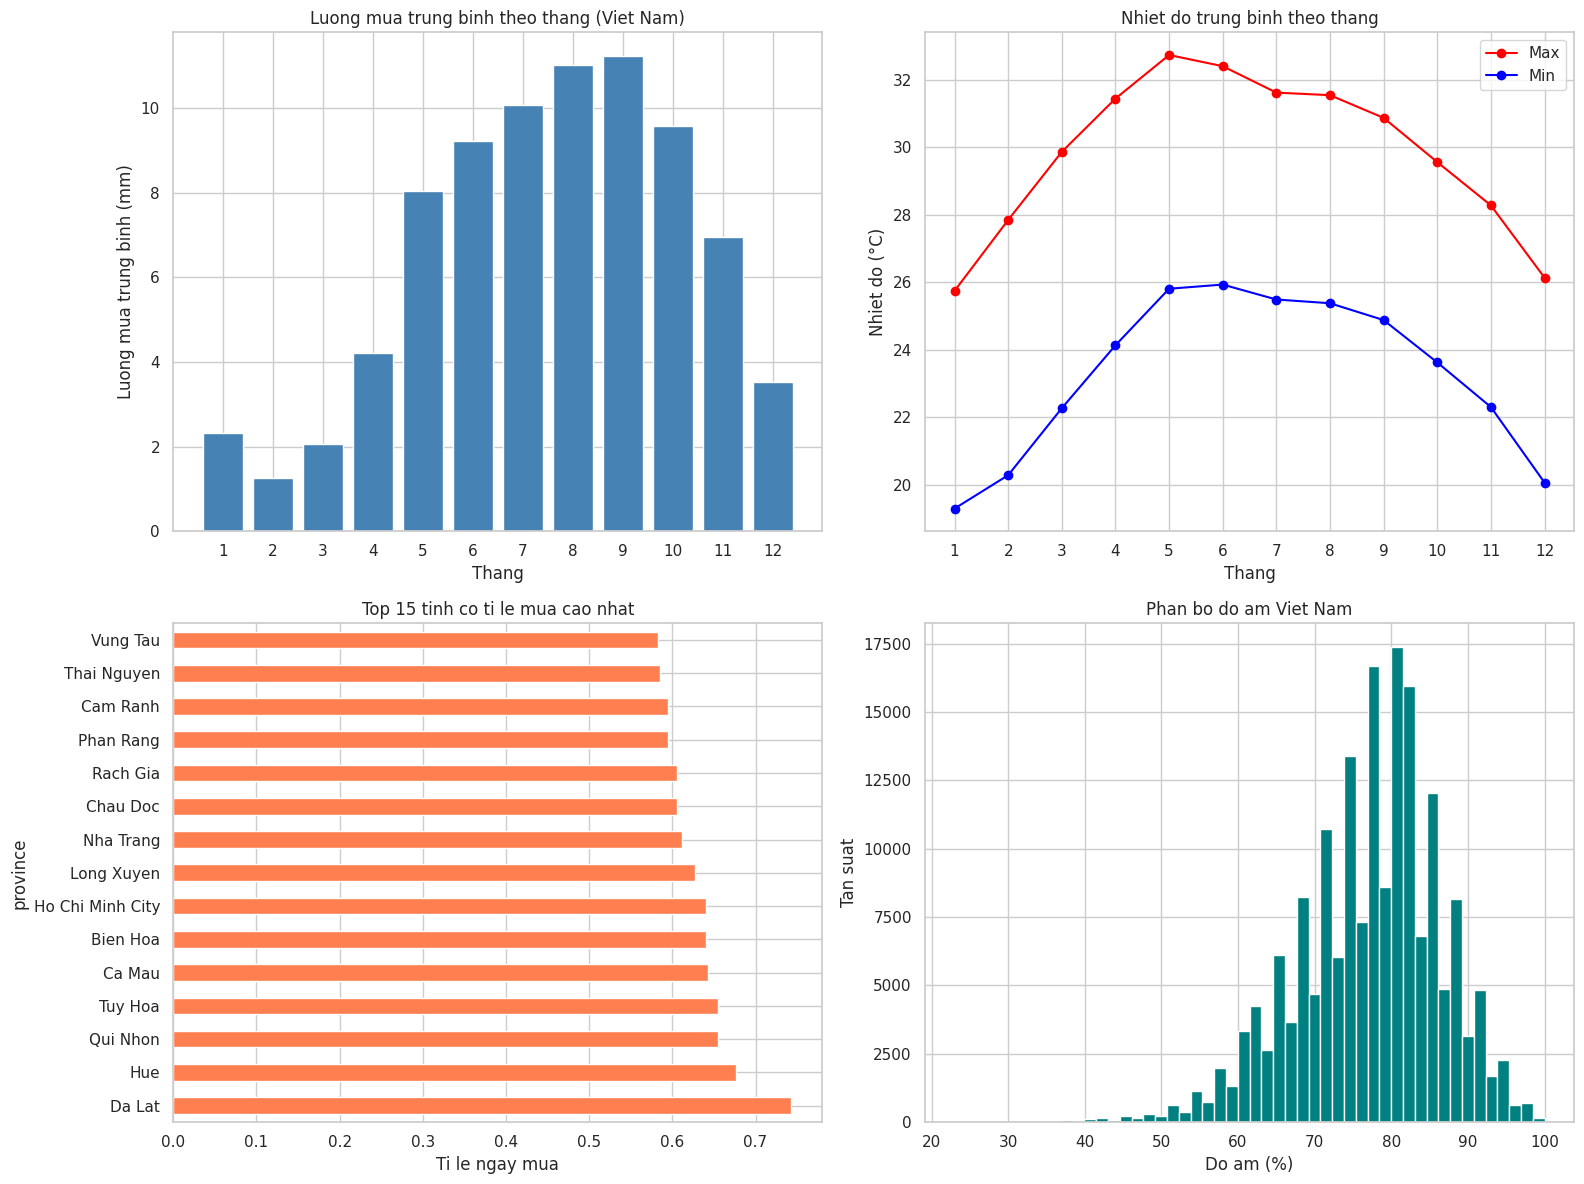

Saved: data/processed/eda_weather.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3.1a: Phan bo luong mua theo thang
if 'month' in df_weather.columns and 'rain_mm' in df_weather.columns:
    monthly_rain = df_weather.groupby('month')['rain_mm'].mean()
    axes[0, 0].bar(monthly_rain.index, monthly_rain.values, color='steelblue')
    axes[0, 0].set_xlabel('Thang')
    axes[0, 0].set_ylabel('Luong mua trung binh (mm)')
    axes[0, 0].set_title('Luong mua trung binh theo thang (Viet Nam)')
    axes[0, 0].set_xticks(range(1, 13))

# 3.1b: Nhiet do trung binh theo thang
if 'month' in df_weather.columns and 'temp_max' in df_weather.columns:
    monthly_temp = df_weather.groupby('month')[['temp_max', 'temp_min']].mean()
    axes[0, 1].plot(monthly_temp.index, monthly_temp['temp_max'], 'r-o', label='Max')
    axes[0, 1].plot(monthly_temp.index, monthly_temp['temp_min'], 'b-o', label='Min')
    axes[0, 1].set_xlabel('Thang')
    axes[0, 1].set_ylabel('Nhiet do (°C)')
    axes[0, 1].set_title('Nhiet do trung binh theo thang')
    axes[0, 1].legend()
    axes[0, 1].set_xticks(range(1, 13))

# 3.1c: Ti le ngay mua theo tinh (top 15)
if 'province' in df_weather.columns and 'is_rainy' in df_weather.columns:
    rain_by_prov = df_weather.groupby('province')['is_rainy'].mean().sort_values(ascending=False).head(15)
    rain_by_prov.plot(kind='barh', ax=axes[1, 0], color='coral')
    axes[1, 0].set_xlabel('Ti le ngay mua')
    axes[1, 0].set_title('Top 15 tinh co ti le mua cao nhat')

# 3.1d: Phan bo do am
if 'humidity' in df_weather.columns:
    axes[1, 1].hist(df_weather['humidity'].dropna(), bins=50, color='teal', edgecolor='white')
    axes[1, 1].set_xlabel('Do am (%)')
    axes[1, 1].set_ylabel('Tan suat')
    axes[1, 1].set_title('Phan bo do am Viet Nam')

plt.tight_layout()
plt.savefig('data/processed/eda_weather.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/processed/eda_weather.png')

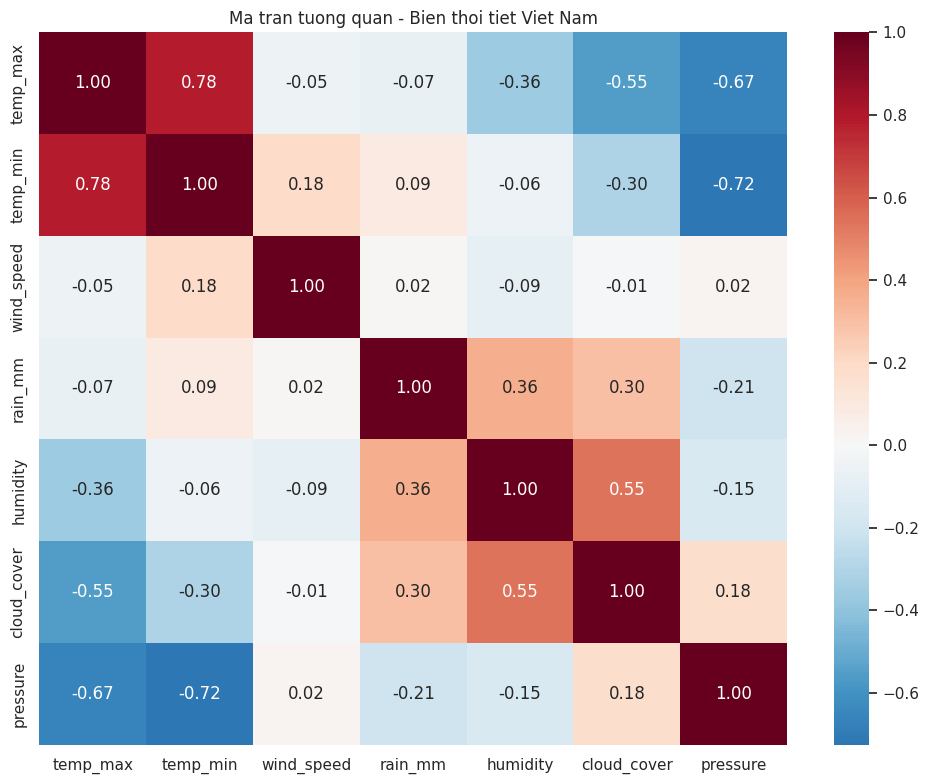

In [20]:
# Correlation matrix cua cac bien thoi tiet
weather_num_cols = ['temp_max', 'temp_min', 'wind_speed', 'rain_mm', 'humidity', 'cloud_cover', 'pressure']
weather_num_cols = [c for c in weather_num_cols if c in df_weather.columns]

if weather_num_cols:
    fig, ax = plt.subplots(figsize=(10, 8))
    corr = df_weather[weather_num_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
    ax.set_title('Ma tran tuong quan - Bien thoi tiet Viet Nam')
    plt.tight_layout()
    plt.savefig('data/processed/eda_weather_corr.png', dpi=150, bbox_inches='tight')
    plt.show()

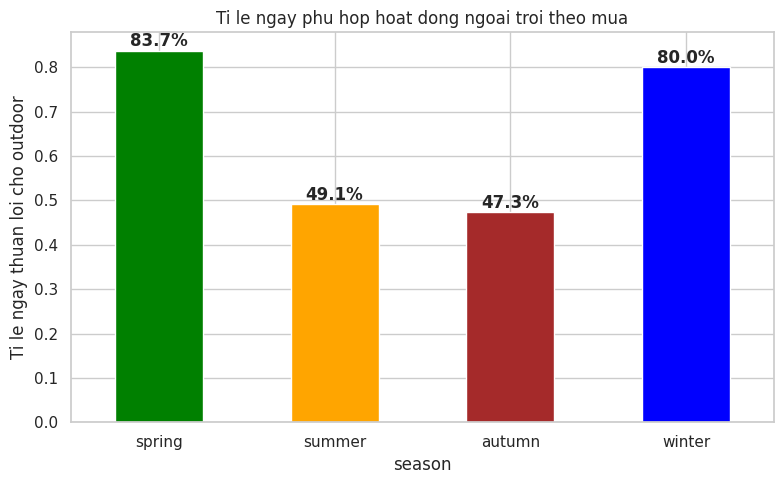

In [21]:
# Ti le outdoor_suitable theo mua
if 'season' in df_weather.columns and 'outdoor_suitable' in df_weather.columns:
    season_outdoor = df_weather.groupby('season')['outdoor_suitable'].mean()
    fig, ax = plt.subplots(figsize=(8, 5))
    season_order = ['spring', 'summer', 'autumn', 'winter']
    season_outdoor = season_outdoor.reindex(season_order)
    season_outdoor.plot(kind='bar', color=['green', 'orange', 'brown', 'blue'], ax=ax)
    ax.set_ylabel('Ti le ngay thuan loi cho outdoor')
    ax.set_title('Ti le ngay phu hop hoat dong ngoai troi theo mua')
    ax.set_xticklabels(season_order, rotation=0)
    for i, v in enumerate(season_outdoor.values):
        ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('data/processed/eda_outdoor_season.png', dpi=150, bbox_inches='tight')
    plt.show()

### 3.2 Hotel Reviews - Review Analysis

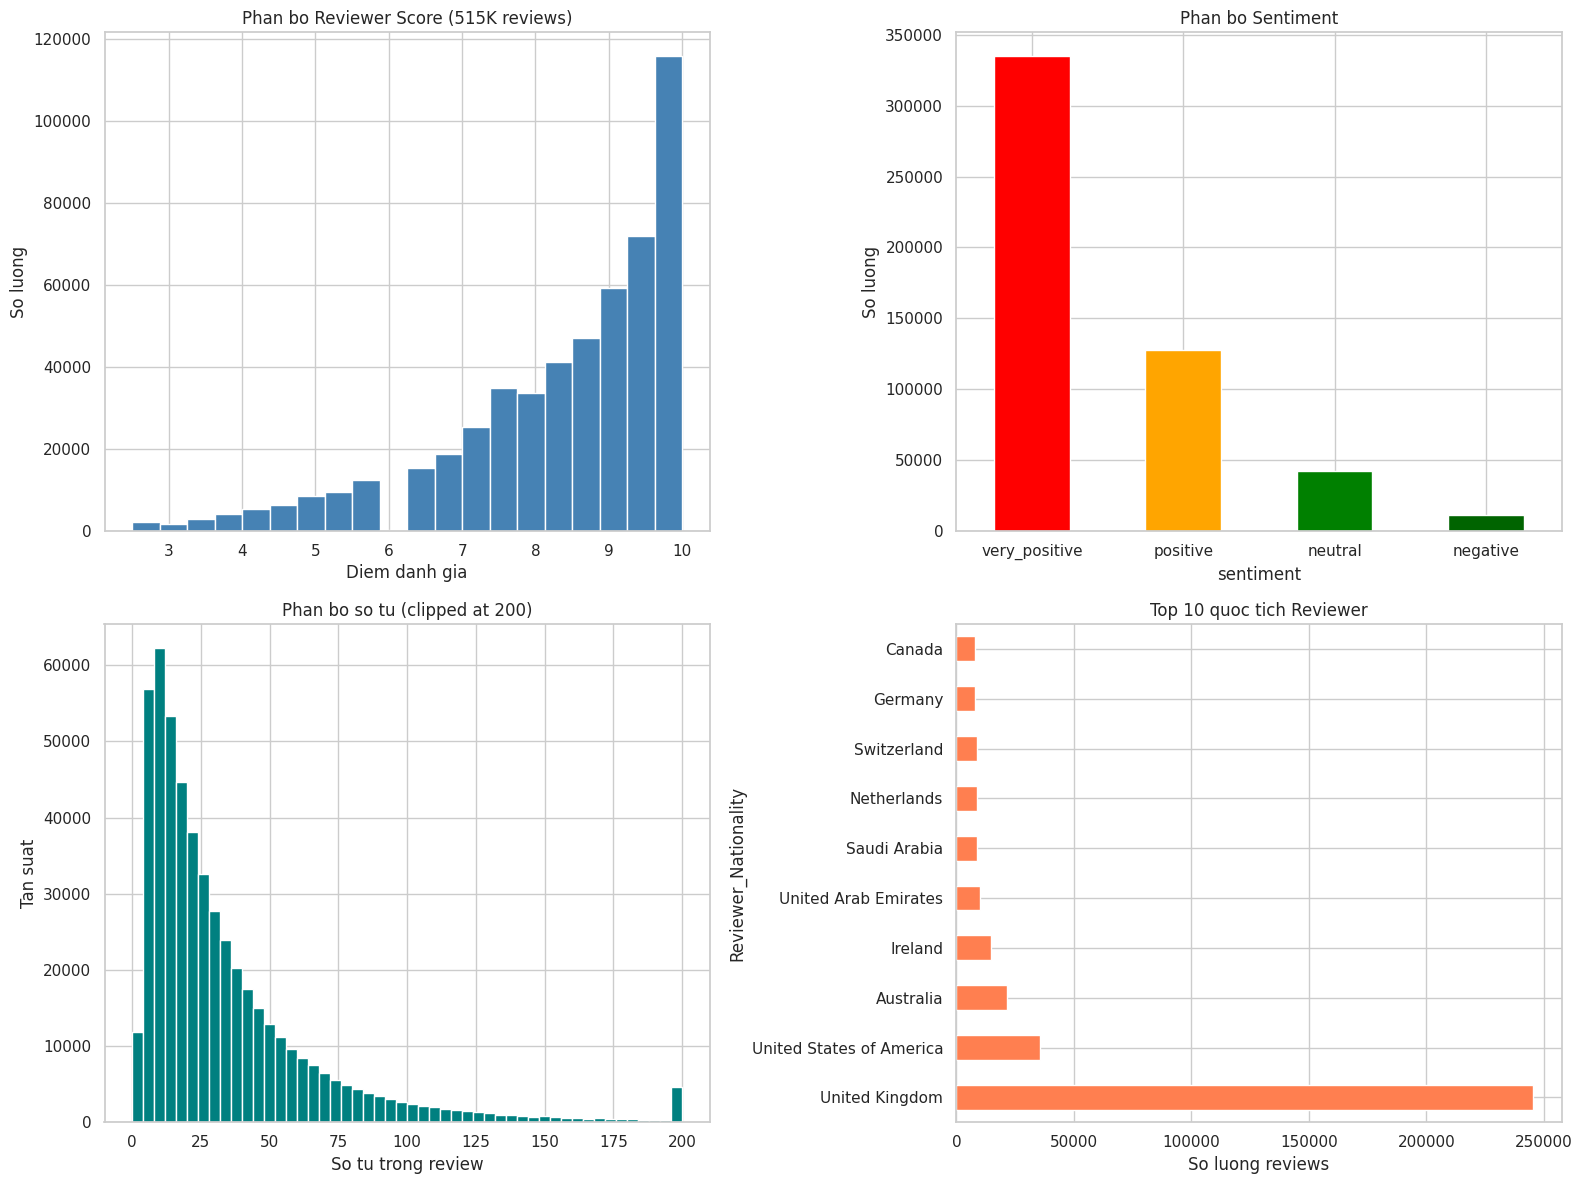

Saved: data/processed/eda_reviews.png


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3.2a: Phan bo diem danh gia
if 'Reviewer_Score' in df_reviews.columns:
    axes[0, 0].hist(df_reviews['Reviewer_Score'].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[0, 0].set_xlabel('Diem danh gia')
    axes[0, 0].set_ylabel('So luong')
    axes[0, 0].set_title('Phan bo Reviewer Score (515K reviews)')

# 3.2b: Sentiment distribution
if 'sentiment' in df_reviews.columns:
    sent_counts = df_reviews['sentiment'].value_counts()
    sent_counts.plot(kind='bar', color=['red', 'orange', 'green', 'darkgreen'], ax=axes[0, 1])
    axes[0, 1].set_title('Phan bo Sentiment')
    axes[0, 1].set_ylabel('So luong')
    axes[0, 1].set_xticklabels(sent_counts.index, rotation=0)

# 3.2c: Phan bo so tu trong review
if 'review_word_count' in df_reviews.columns:
    axes[1, 0].hist(df_reviews['review_word_count'].clip(upper=200), bins=50, color='teal', edgecolor='white')
    axes[1, 0].set_xlabel('So tu trong review')
    axes[1, 0].set_ylabel('Tan suat')
    axes[1, 0].set_title('Phan bo so tu (clipped at 200)')

# 3.2d: Top 10 quoc tich reviewer
if 'Reviewer_Nationality' in df_reviews.columns:
    top_nations = df_reviews['Reviewer_Nationality'].str.strip().value_counts().head(10)
    top_nations.plot(kind='barh', color='coral', ax=axes[1, 1])
    axes[1, 1].set_xlabel('So luong reviews')
    axes[1, 1].set_title('Top 10 quoc tich Reviewer')

plt.tight_layout()
plt.savefig('data/processed/eda_reviews.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/processed/eda_reviews.png')

### 3.3 Travel Ratings - User Preference Analysis

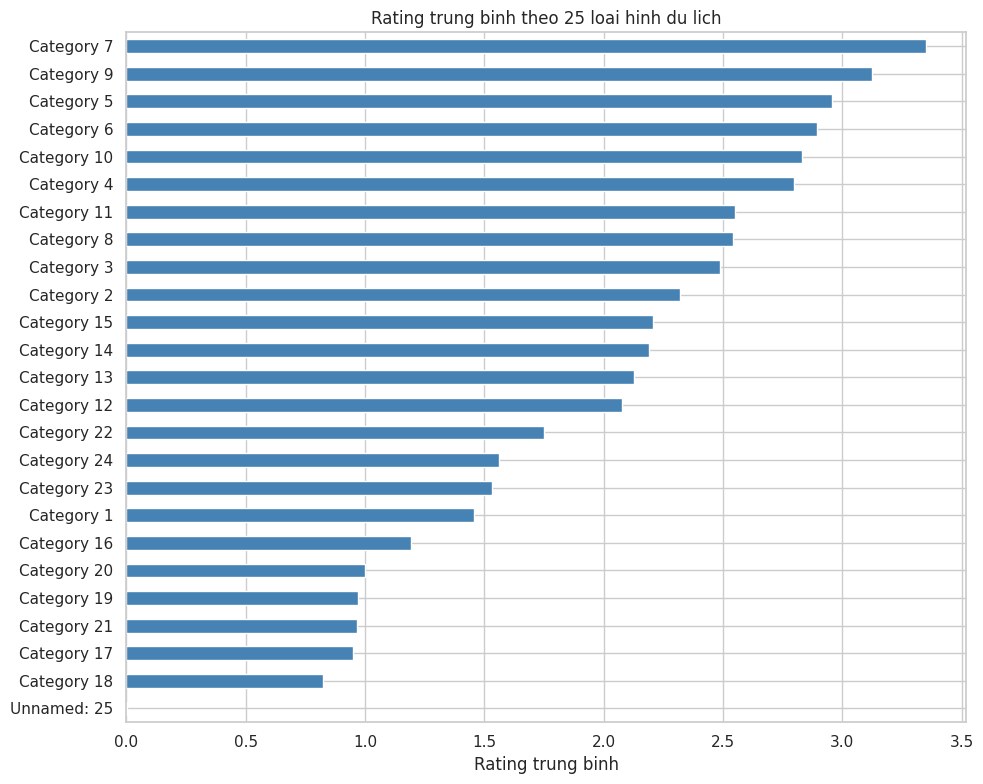

In [23]:
# Rating trung binh theo loai hinh
category_cols = [c for c in df_ratings.columns if c not in [
    'User', 'User Id', 'Unnamed: 0', 'top_category', 'avg_rating', 'rating_std', 'num_rated'
]]
# Chi lay cot co kieu so
category_cols = [c for c in category_cols if df_ratings[c].dtype in ['float64', 'int64']]

if category_cols:
    avg_by_cat = df_ratings[category_cols].mean().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    avg_by_cat.plot(kind='barh', color='steelblue', ax=ax)
    ax.set_xlabel('Rating trung binh')
    ax.set_title(f'Rating trung binh theo {len(category_cols)} loai hinh du lich')
    plt.tight_layout()
    plt.savefig('data/processed/eda_ratings.png', dpi=150, bbox_inches='tight')
    plt.show()

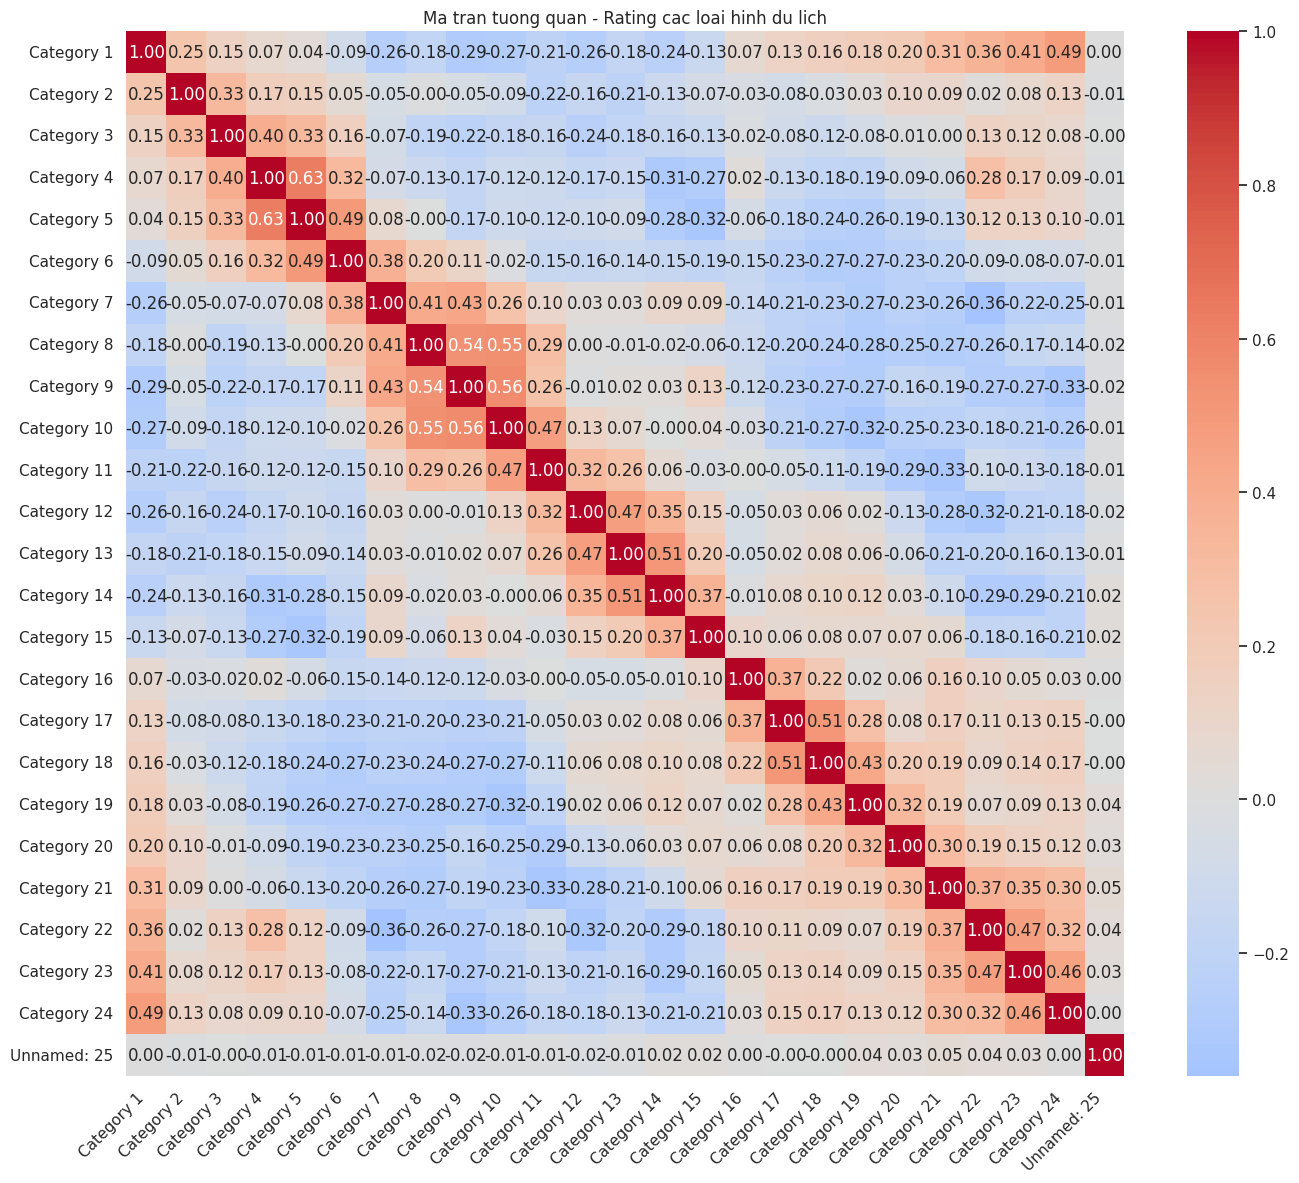

In [24]:
# Correlation heatmap cua cac loai hinh
if len(category_cols) >= 5:
    fig, ax = plt.subplots(figsize=(14, 12))
    corr = df_ratings[category_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=ax, xticklabels=True, yticklabels=True)
    ax.set_title('Ma tran tuong quan - Rating cac loai hinh du lich')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('data/processed/eda_ratings_corr.png', dpi=150, bbox_inches='tight')
    plt.show()

### 3.4 Traveler Trips - Travel Cost Analysis

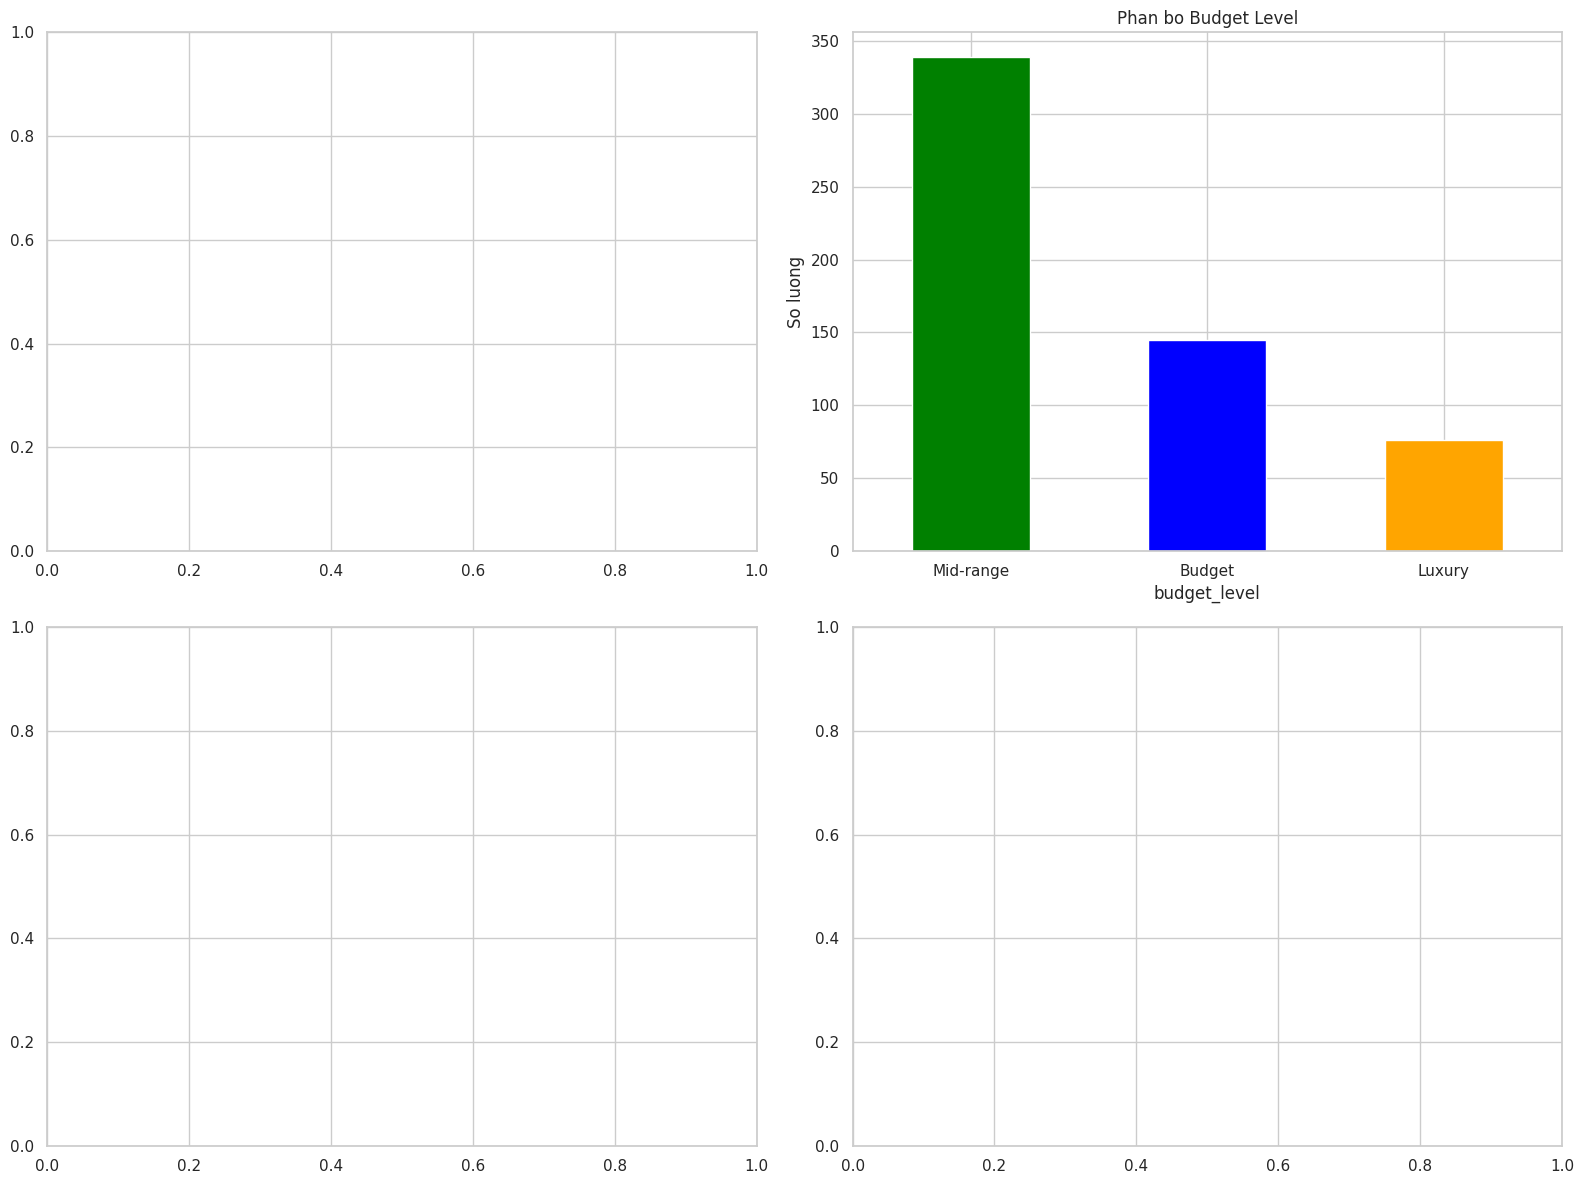

Saved: data/processed/eda_trips.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3.4a: Phan bo tong chi phi
if 'total_cost' in df_trips.columns:
    axes[0, 0].hist(df_trips['total_cost'].clip(upper=10000), bins=50, color='steelblue', edgecolor='white')
    axes[0, 0].set_xlabel('Tong chi phi ($)')
    axes[0, 0].set_ylabel('So luong')
    axes[0, 0].set_title('Phan bo tong chi phi (clipped at $10,000)')

# 3.4b: Budget level distribution
if 'budget_level' in df_trips.columns:
    budget_counts = df_trips['budget_level'].value_counts()
    budget_counts.plot(kind='bar', color=['green', 'blue', 'orange', 'red'], ax=axes[0, 1])
    axes[0, 1].set_title('Phan bo Budget Level')
    axes[0, 1].set_ylabel('So luong')
    axes[0, 1].set_xticklabels(budget_counts.index, rotation=0)

# 3.4c: Duration distribution
if 'Duration (days)' in df_trips.columns:
    axes[1, 0].hist(df_trips['Duration (days)'].dropna(), bins=30, color='teal', edgecolor='white')
    axes[1, 0].set_xlabel('So ngay')
    axes[1, 0].set_ylabel('Tan suat')
    axes[1, 0].set_title('Phan bo thoi gian du lich')

# 3.4d: Top destinations
if 'Destination' in df_trips.columns:
    top_dest = df_trips['Destination'].value_counts().head(15)
    top_dest.plot(kind='barh', color='coral', ax=axes[1, 1])
    axes[1, 1].set_xlabel('So luong trips')
    axes[1, 1].set_title('Top 15 diem den pho bien')

plt.tight_layout()
plt.savefig('data/processed/eda_trips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/processed/eda_trips.png')

---
## 4. Feature Engineering

### 4.1 Distance Matrix - Vietnam Tourist Spots
Used for (A) A* and (B) CSP

In [26]:
# Build & save distance matrix
place_names, dist_matrix = build_distance_matrix()
save_features(dist_matrix, 'distance_matrix')

# Hien thi
df_dist = pd.DataFrame(dist_matrix, index=place_names, columns=place_names)
print(f'Ma tran khoang cach: {dist_matrix.shape[0]} x {dist_matrix.shape[1]} diem')
print(f'Khoang cach min (> 0): {dist_matrix[dist_matrix > 0].min():.1f} km')
print(f'Khoang cach max: {dist_matrix.max():.1f} km')
df_dist.head(10)

[FEATURE] Distance matrix: 30x30 places
[SAVE] /content/Introduction-AI-Assignment/data/features/distance_matrix.npy (shape: (30, 30))
Ma tran khoang cach: 30 x 30 diem
Khoang cach min (> 0): 0.4 km
Khoang cach max: 1353.1 km


,Ha Long Bay,Hoan Kiem Lake,Temple of Literature,Ho Chi Minh Mausoleum,Old Quarter Hanoi,Imperial City Hue,Marble Mountains,Golden Bridge,My Son Sanctuary,Hoi An Ancient Town,Cu Chi Tunnels,Ben Thanh Market,Notre Dame Cathedral HCMC,War Remnants Museum,Nha Trang Beach,Vinpearl Nha Trang,Po Nagar Towers,Xuan Huong Lake,Crazy House Da Lat,Valley of Love,Mui Ne Sand Dunes,Phu Quoc Beach,Sapa,Fansipan Summit,Trang An Landscape,Bai Dinh Pagoda,Phong Nha Cave,Son Doong Cave,Cat Ba Island,Ba Na Hills
Ha Long Bay,0.00,138.87,140.56,140.76,139.18,495.48,557.33,553.33,580.71,572.40,1088.94,1128.44,1127.63,1127.71,986.88,990.99,984.79,1005.72,1006.64,1003.48,1115.60,1229.46,379.93,384.95,152.48,154.54,380.87,388.57,24.94,552.93
Hoan Kiem Lake,138.87,0.00,1.72,2.03,0.63,538.51,613.83,603.74,632.50,629.63,1101.34,1144.02,1143.21,1143.20,1039.34,1043.84,1037.31,1046.90,1047.66,1044.69,1152.24,1210.69,253.40,257.24,86.74,84.04,384.82,387.43,128.45,603.36
Temple of Literature,140.56,1.72,0.00,1.05,1.62,538.96,614.42,604.26,633.03,630.22,1101.30,1144.01,1143.21,1143.20,1039.81,1044.32,1037.78,1047.22,1047.98,1045.02,1152.50,1210.26,252.09,255.90,86.71,83.94,384.88,387.43,130.07,603.88
Ho Chi Minh Mausoleum,140.76,2.03,1.05,0.00,1.59,539.98,615.41,605.27,634.03,631.21,1102.35,1145.06,1144.26,1144.25,1040.83,1045.33,1038.80,1048.26,1049.02,1046.05,1153.54,1211.27,251.40,255.23,87.76,84.99,385.93,388.48,130.43,604.89
Old Quarter Hanoi,139.18,0.63,1.62,1.59,0.00,539.14,614.46,604.38,633.13,630.26,1101.94,1144.61,1143.81,1143.80,1039.98,1044.48,1037.95,1047.52,1048.29,1045.32,1152.86,1211.22,252.86,256.70,87.33,84.62,385.43,388.03,128.85,604.00
Imperial City Hue,495.48,538.51,538.96,539.98,539.14,0.00,89.58,69.24,97.71,104.29,604.60,640.61,639.79,639.95,500.88,505.41,498.86,511.54,512.40,509.31,620.36,789.46,760.77,761.40,456.13,459.95,185.82,194.31,476.66,68.90
Marble Mountains,557.33,613.83,614.42,615.41,614.46,89.58,0.00,28.44,30.44,15.89,574.54,605.76,604.95,605.20,429.70,433.89,427.62,451.57,452.60,449.34,563.78,786.17,843.20,844.17,534.12,538.14,274.94,283.79,540.67,28.48
Golden Bridge,553.33,603.74,604.26,605.27,604.38,69.24,28.44,0.00,28.93,38.61,564.47,597.35,596.54,596.76,436.31,440.69,434.25,452.66,453.62,450.43,563.60,768.72,829.07,829.81,522.53,526.45,254.64,262.58,535.73,0.39
My Son Sanctuary,580.71,632.50,633.03,634.03,633.13,97.71,30.44,28.93,0.00,26.25,544.52,576.12,575.31,575.55,407.91,412.26,405.85,425.96,426.95,423.73,537.48,756.00,857.96,858.68,551.41,555.34,282.37,289.89,563.40,29.30
Hoi An Ancient Town,572.40,629.63,630.22,631.21,630.26,104.29,15.89,38.61,26.25,0.00,564.55,594.99,594.19,594.46,414.51,418.66,412.42,437.59,438.65,435.36,550.09,780.10,859.08,860.04,549.99,554.02,289.99,298.60,555.90,38.79


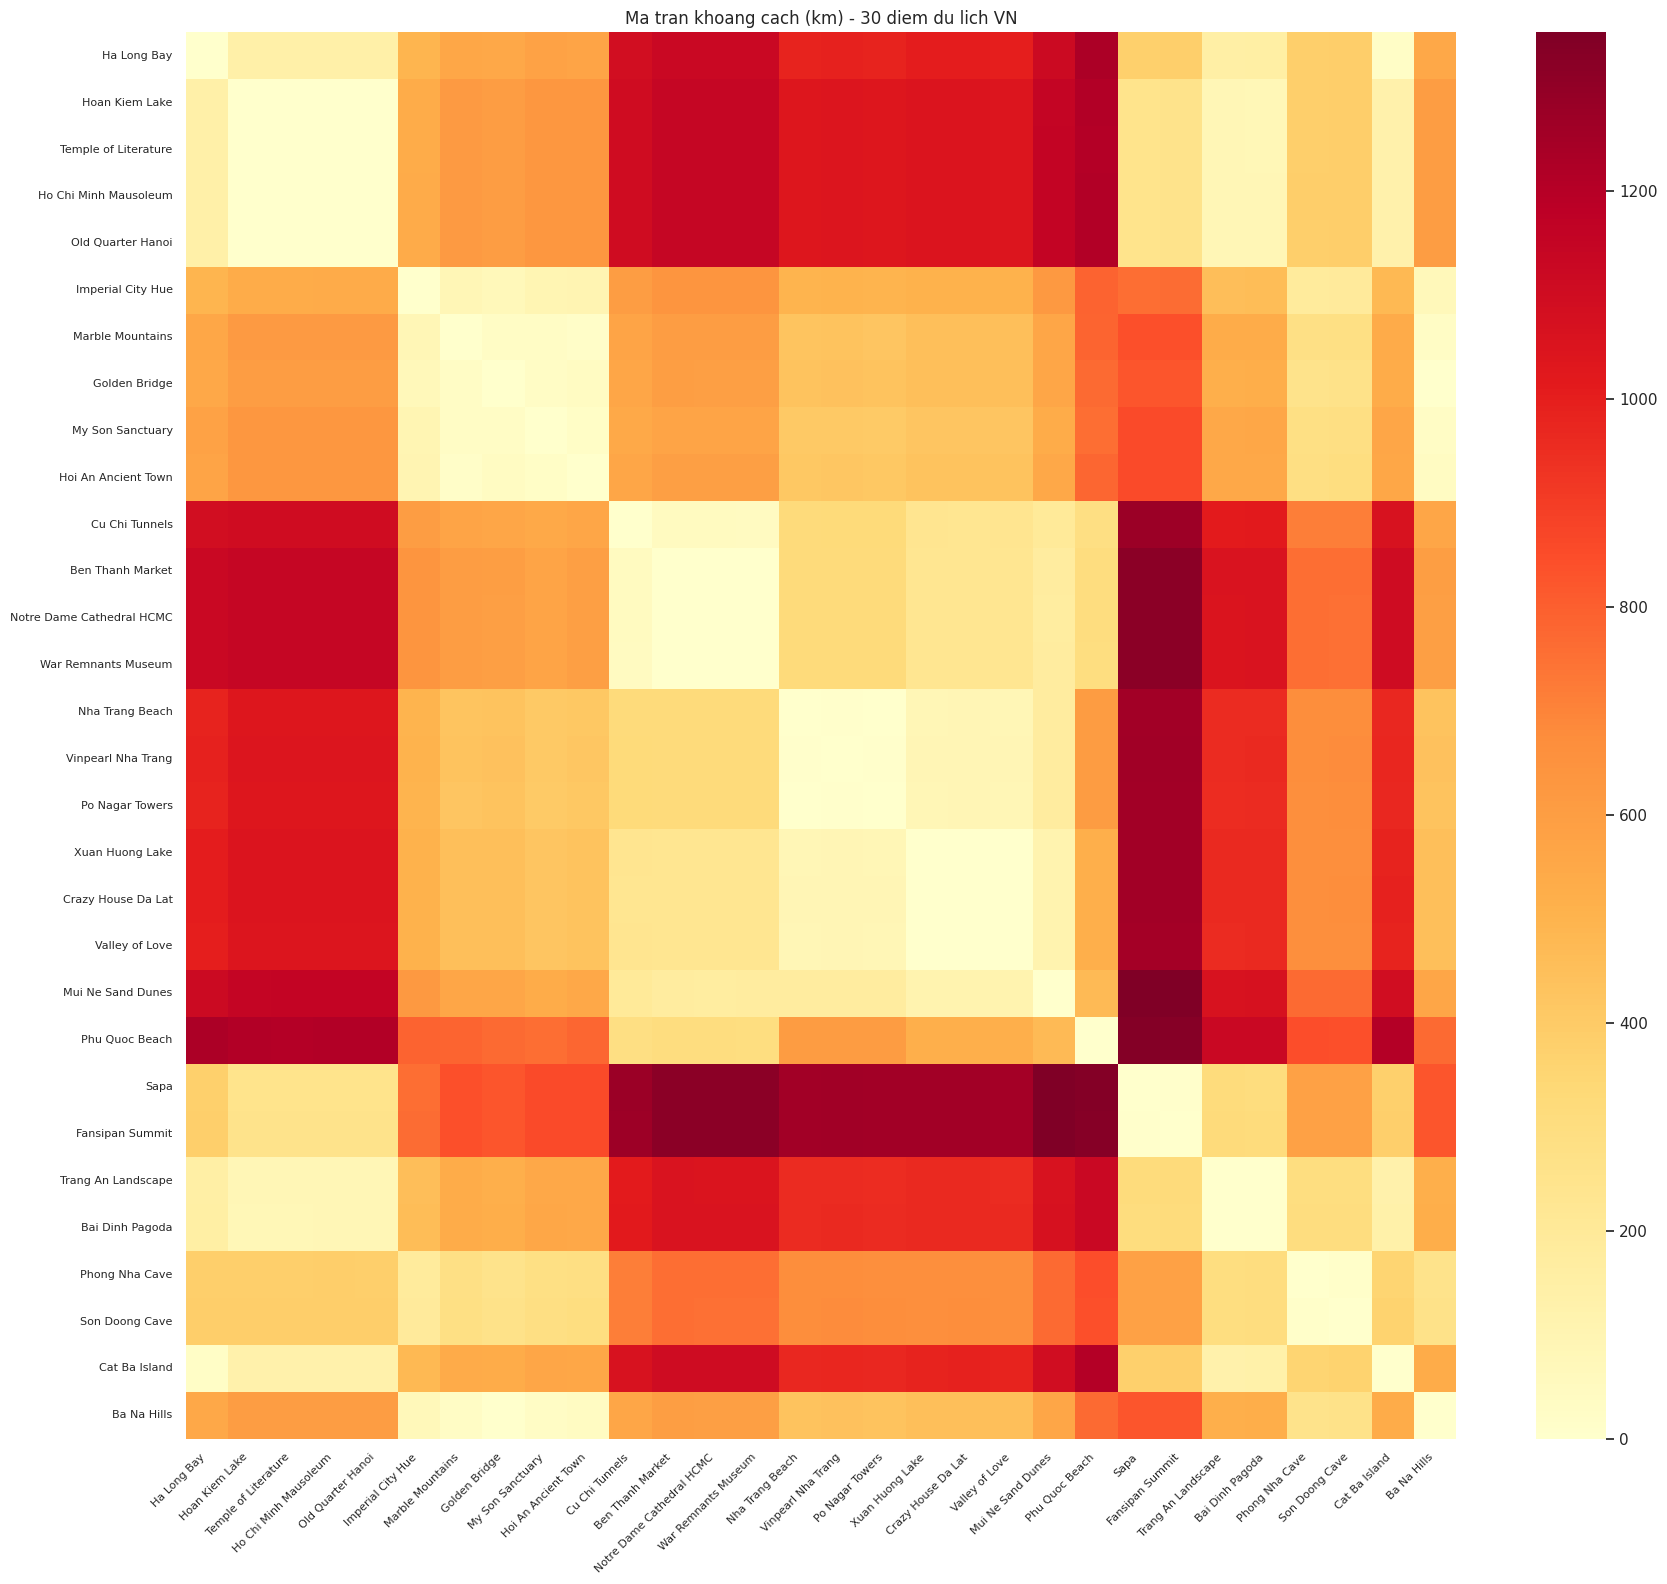

In [27]:
# Visualize distance matrix (heatmap)
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(df_dist, cmap='YlOrRd', ax=ax, fmt='.0f',
            xticklabels=True, yticklabels=True)
ax.set_title(f'Ma tran khoang cach (km) - {len(place_names)} diem du lich VN')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('data/processed/distance_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Cost matrix & Travel time matrix
_, cost_matrix = build_cost_matrix()
save_features(cost_matrix, 'cost_matrix')

_, time_matrix = build_travel_time_matrix()
save_features(time_matrix, 'travel_time_matrix')

print(f'Cost matrix range: {cost_matrix[cost_matrix > 0].min():,.0f} - {cost_matrix.max():,.0f} VND')
print(f'Time matrix range: {time_matrix[time_matrix > 0].min():.1f} - {time_matrix.max():.1f} hours')

[FEATURE] Distance matrix: 30x30 places
[FEATURE] Cost matrix: 30x30 places (VND)
[SAVE] /content/Introduction-AI-Assignment/data/features/cost_matrix.npy (shape: (30, 30))
[FEATURE] Distance matrix: 30x30 places
[FEATURE] Travel time matrix: 30x30 places (hours)
[SAVE] /content/Introduction-AI-Assignment/data/features/travel_time_matrix.npy (shape: (30, 30))
Cost matrix range: 1,170 - 4,059,270 VND
Time matrix range: 0.0 - 33.8 hours


### 4.2 Places DataFrame - Tourist Spot Information

In [29]:
df_places = build_places_dataframe()
save_feature_csv(df_places, 'vn_tourist_places')

print(f'\nSo diem du lich: {len(df_places)}')
print(f'\nPhan bo theo category:')
print(df_places['category'].value_counts())
print(f'\nPhan bo theo tinh:')
print(df_places['province'].value_counts())
df_places

[FEATURE] Places DataFrame: 30 places
[SAVE] /content/Introduction-AI-Assignment/data/features/vn_tourist_places.csv (30 rows)

So diem du lich: 30

Phan bo theo category:
category
culture          14
nature           10
beach             2
entertainment     2
adventure         2
Name: count, dtype: int64

Phan bo theo tinh:
province
Ha Noi         4
Ho Chi Minh    4
Da Nang        3
Khanh Hoa      3
Lam Dong       3
Quang Nam      2
Quang Binh     2
Lao Cai        2
Ninh Binh      2
Quang Ninh     1
Hue            1
Binh Thuan     1
Kien Giang     1
Hai Phong      1
Name: count, dtype: int64


,place_name,latitude,longitude,category,province,entry_fee_vnd,visit_duration_hours,opening_hour,closing_hour
0,Ha Long Bay,20.9101,107.1839,nature,Quang Ninh,0,3.0,7,17
1,Hoan Kiem Lake,21.0288,105.8525,culture,Ha Noi,0,2.0,7,17
2,Temple of Literature,21.0275,105.8360,culture,Ha Noi,30000,2.0,7,17
3,Ho Chi Minh Mausoleum,21.0369,105.8350,culture,Ha Noi,0,2.0,7,17
4,Old Quarter Hanoi,21.0340,105.8500,culture,Ha Noi,0,2.0,7,17
5,Imperial City Hue,16.4698,107.5786,culture,Hue,200000,2.0,7,17
6,Marble Mountains,16.0034,108.2628,nature,Da Nang,40000,3.0,7,17
7,Golden Bridge,15.9940,107.9969,nature,Da Nang,900000,3.0,7,17
8,My Son Sanctuary,15.7644,108.1241,culture,Quang Nam,150000,2.0,7,17
9,Hoi An Ancient Town,15.8801,108.3380,culture,Quang Nam,120000,2.0,7,17


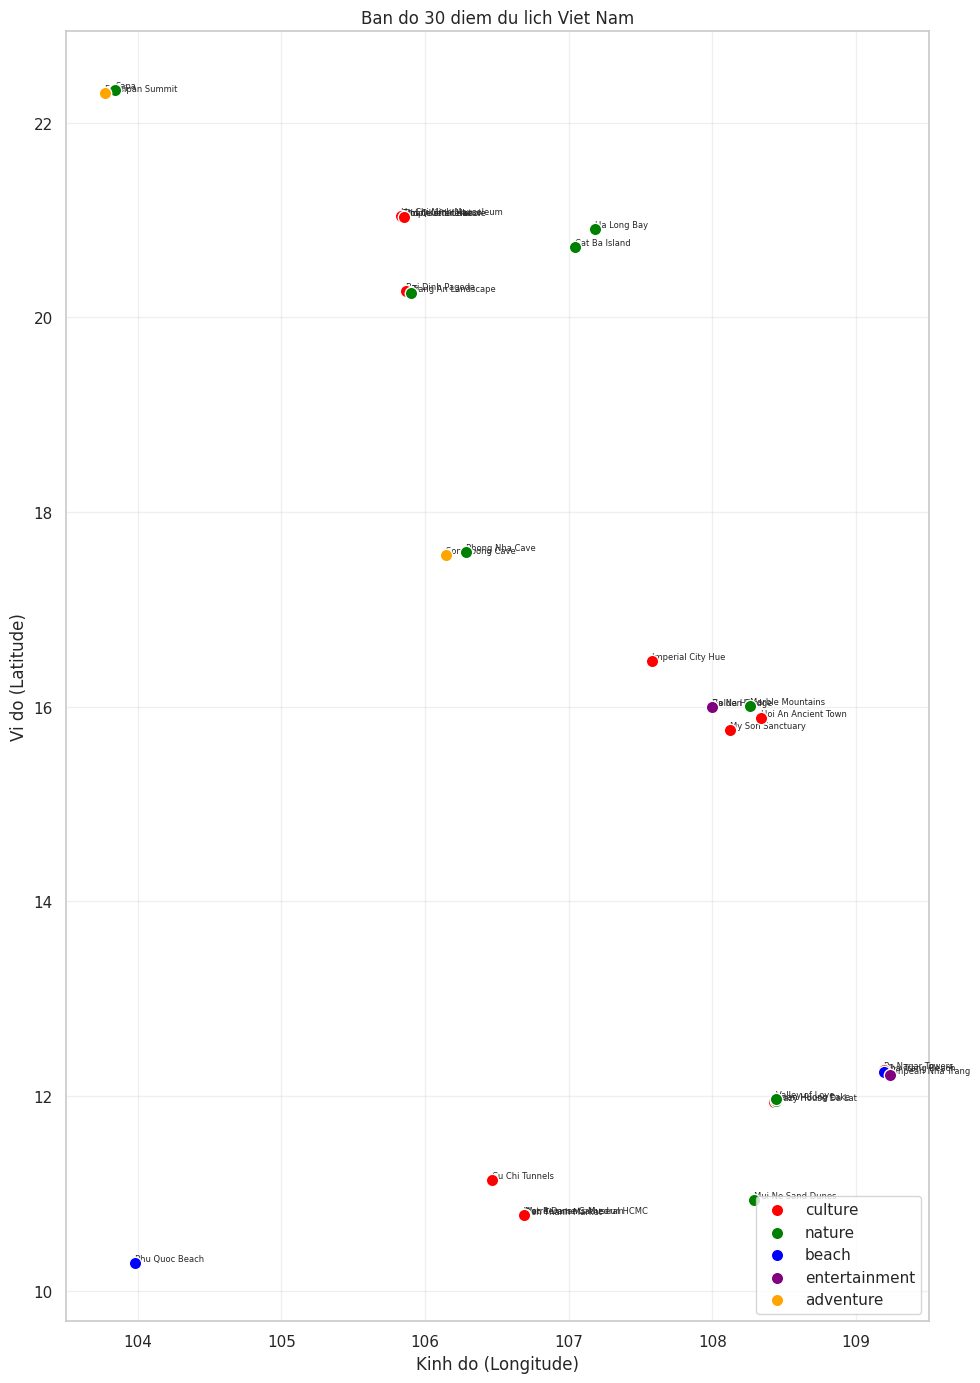

In [30]:
# Map cac diem du lich (scatter plot)
fig, ax = plt.subplots(figsize=(10, 14))
colors = {'culture': 'red', 'nature': 'green', 'beach': 'blue',
          'entertainment': 'purple', 'adventure': 'orange'}
for cat, color in colors.items():
    subset = df_places[df_places['category'] == cat]
    ax.scatter(subset['longitude'], subset['latitude'],
               c=color, label=cat, s=80, edgecolors='white', zorder=5)
    for _, row in subset.iterrows():
        ax.annotate(row['place_name'], (row['longitude'], row['latitude']),
                     fontsize=6, ha='left', va='bottom')

ax.set_xlabel('Kinh do (Longitude)')
ax.set_ylabel('Vi do (Latitude)')
ax.set_title(f'Ban do {len(df_places)} diem du lich Viet Nam')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/processed/places_map.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Weather Probability Table - For Bayesian Network

In [31]:
weather_probs = build_weather_probability_table(df_weather)
save_feature_csv(weather_probs, 'weather_probabilities')

print(f'\nBang xac suat: {weather_probs.shape[0]} dong (tinh x thang)')
print(f'\nVi du - Ha Noi:')
weather_probs[weather_probs['province'].str.contains('Ha Noi|Hanoi|Ha noi', case=False, na=False)]

[FEATURE] Weather probability table: 480 rows (province x month)
[SAVE] /content/Introduction-AI-Assignment/data/features/weather_probabilities.csv (480 rows)

Bang xac suat: 480 dong (tinh x thang)

Vi du - Ha Noi:


,province,month,p_rain,p_outdoor_ok,p_hot,p_humid
120,Ha Noi,1,0.240695,0.928040,0.000000,0.282878
121,Ha Noi,2,0.186813,0.964286,0.043956,0.219780
122,Ha Noi,3,0.270471,0.915633,0.039702,0.272953
123,Ha Noi,4,0.451282,0.779487,0.148718,0.407692
124,Ha Noi,5,0.602978,0.461538,0.399504,0.250620
125,Ha Noi,6,0.711640,0.410053,0.582011,0.171958
126,Ha Noi,7,0.795699,0.387097,0.387097,0.381720
127,Ha Noi,8,0.793011,0.440860,0.282258,0.510753
128,Ha Noi,9,0.683333,0.577778,0.091667,0.508333
129,Ha Noi,10,0.427419,0.803763,0.010753,0.268817


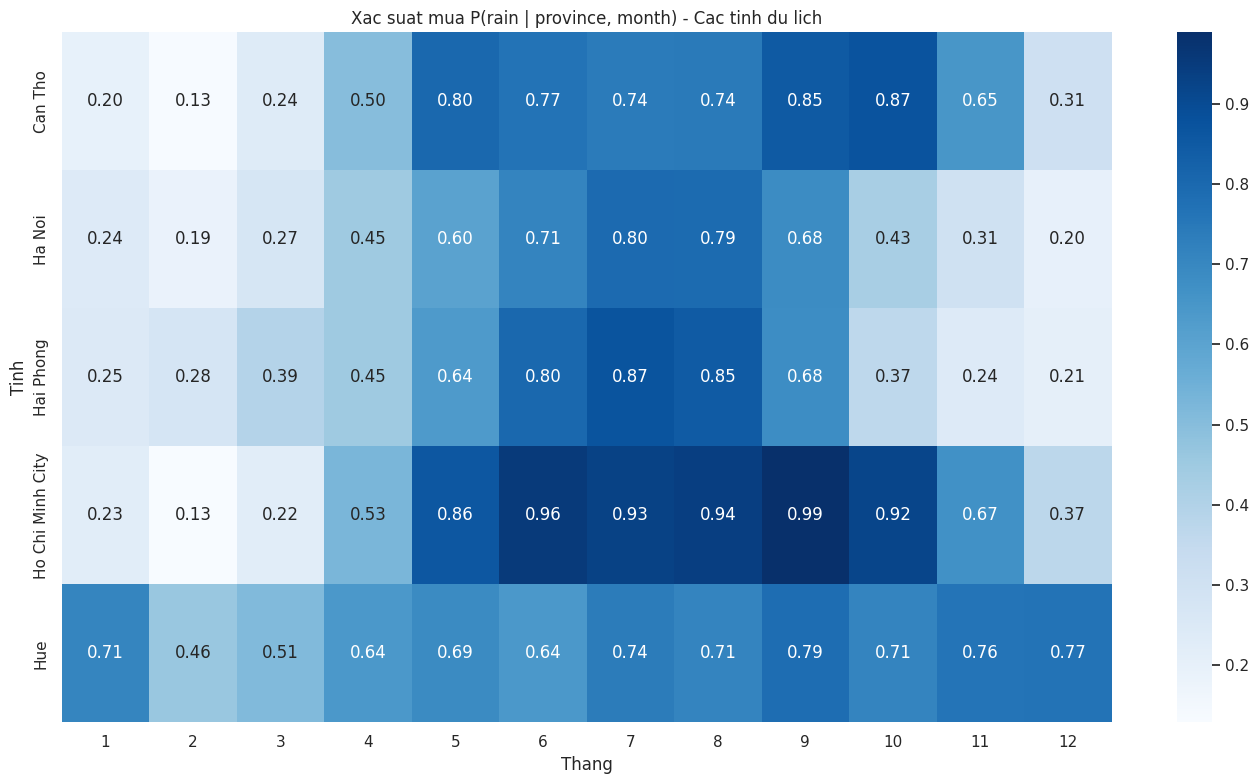

In [32]:
# Heatmap xac suat mua theo tinh x thang (top 15 tinh du lich)
tourist_provinces = ['Ha Noi', 'Ho Chi Minh', 'Da Nang', 'Hue',
                     'Khanh Hoa', 'Lam Dong', 'Quang Ninh', 'Quang Binh',
                     'Quang Nam', 'Binh Thuan', 'Kien Giang', 'Lao Cai',
                     'Ninh Binh', 'Hai Phong', 'Can Tho']

# Tim cac tinh co trong du lieu
available_provinces = []
for tp in tourist_provinces:
    matches = weather_probs[weather_probs['province'].str.contains(tp, case=False, na=False)]
    if len(matches) > 0:
        available_provinces.append(matches['province'].iloc[0])

if available_provinces:
    subset = weather_probs[weather_probs['province'].isin(available_provinces)]
    pivot = subset.pivot_table(index='province', columns='month', values='p_rain')

    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues', ax=ax)
    ax.set_title('Xac suat mua P(rain | province, month) - Cac tinh du lich')
    ax.set_xlabel('Thang')
    ax.set_ylabel('Tinh')
    plt.tight_layout()
    plt.savefig('data/processed/weather_rain_prob_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Khong tim thay tinh du lich trong du lieu. Kiem tra ten tinh.')

### 4.4 Text Features - From Hotel Reviews for ML

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Lay sample 50K reviews de TF-IDF (tiet kiem RAM)
if 'full_review' in df_reviews.columns:
    sample_reviews = df_reviews[['full_review', 'sentiment_binary', 'Reviewer_Score']].dropna()
    sample_reviews = sample_reviews[sample_reviews['full_review'].str.len() > 20]

    if len(sample_reviews) > 50000:
        sample_reviews = sample_reviews.sample(50000, random_state=42)

    print(f'Sample size: {len(sample_reviews):,} reviews')

    # TF-IDF vectorization (top 5000 features)
    tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
    X_tfidf = tfidf.fit_transform(sample_reviews['full_review'])

    print(f'TF-IDF matrix: {X_tfidf.shape}')
    print(f'Top 20 features: {tfidf.get_feature_names_out()[:20].tolist()}')

    # Save
    from scipy import sparse
    sparse.save_npz('data/features/review_tfidf.npz', X_tfidf)
    np.save('data/features/review_labels.npy', sample_reviews['sentiment_binary'].values)
    np.save('data/features/review_scores.npy', sample_reviews['Reviewer_Score'].values)

    # Save TF-IDF feature names
    pd.DataFrame({'feature': tfidf.get_feature_names_out()}).to_csv(
        'data/features/tfidf_features.csv', index=False)

    print(f'\nSaved:')
    print(f'  data/features/review_tfidf.npz ({X_tfidf.shape})')
    print(f'  data/features/review_labels.npy ({len(sample_reviews):,})')
    print(f'  data/features/review_scores.npy ({len(sample_reviews):,})')
else:
    print('Cot full_review khong ton tai. Kiem tra lai.')

Sample size: 50,000 reviews
TF-IDF matrix: (50000, 5000)
Top 20 features: ['00', '00am', '00pm', '02', '10', '10 10', '10 15', '10 30', '10 min', '10 mins', '10 minute', '10 minutes', '100', '10am', '10pm', '11', '11am', '11pm', '12', '13']

Saved:
  data/features/review_tfidf.npz ((50000, 5000))
  data/features/review_labels.npy (50,000)
  data/features/review_scores.npy (50,000)


### 4.5 User Feature Vectors - From Travel Ratings for User Classification

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Lay cac cot rating
cat_cols = [c for c in df_ratings.columns if c not in [
    'User', 'User Id', 'Unnamed: 0', 'top_category', 'avg_rating', 'rating_std', 'num_rated'
] and df_ratings[c].dtype in ['float64', 'int64']]

if cat_cols:
    X_ratings = df_ratings[cat_cols].values

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_ratings)

    # K-Means clustering de tao nhan traveler_type
    # Chon k=5 (5 loai khach du lich)
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    df_ratings['cluster'] = labels

    # Dat ten cluster dua tren dac trung trung binh
    cluster_means = df_ratings.groupby('cluster')[cat_cols].mean()
    print('Dac trung trung binh cua cac cluster:')
    print(cluster_means.T)

    # Save
    np.save('data/features/user_features.npy', X_scaled)
    np.save('data/features/user_cluster_labels.npy', labels)
    save_cleaned(df_ratings, 'travel_ratings_clustered')

    print(f'\nPhan bo clusters:')
    print(df_ratings['cluster'].value_counts().sort_index())
    print(f'\nSaved: user_features.npy ({X_scaled.shape}), user_cluster_labels.npy ({len(labels)})')

Dac trung trung binh cua cac cluster:
cluster             0         1         2         3         4
Category 1   0.708305  1.766206  2.344601  1.478314  1.171931
Category 2   1.002209  1.961897  2.864325  2.587545  2.239673
Category 3   1.645788  2.039605  2.718087  3.214542  1.972766
Category 4   1.632312  2.027826  2.558852  3.966168  2.219334
Category 5   1.698527  2.009802  2.190287  4.386650  2.449062
Category 6   1.737329  1.854664  1.985080  3.705518  3.054233
Category 7   3.007277  2.643715  1.953719  3.390661  4.236705
Category 8   1.988236  1.954150  1.514389  2.363480  3.503213
Category 9   2.845257  2.265534  1.999564  2.601734  4.440240
Category 10  2.915257  2.099051  1.644718  2.544054  3.808151
Category 11  3.281473  2.070198  1.428831  2.383946  3.124708
Category 12  4.120223  2.052411  1.274910  1.962157  1.959629
Category 13  4.397723  2.104229  1.369373  2.016374  1.902542
Category 14  4.723014  2.764348  1.637131  1.602515  2.181418
Category 15  3.867021  3.241621 

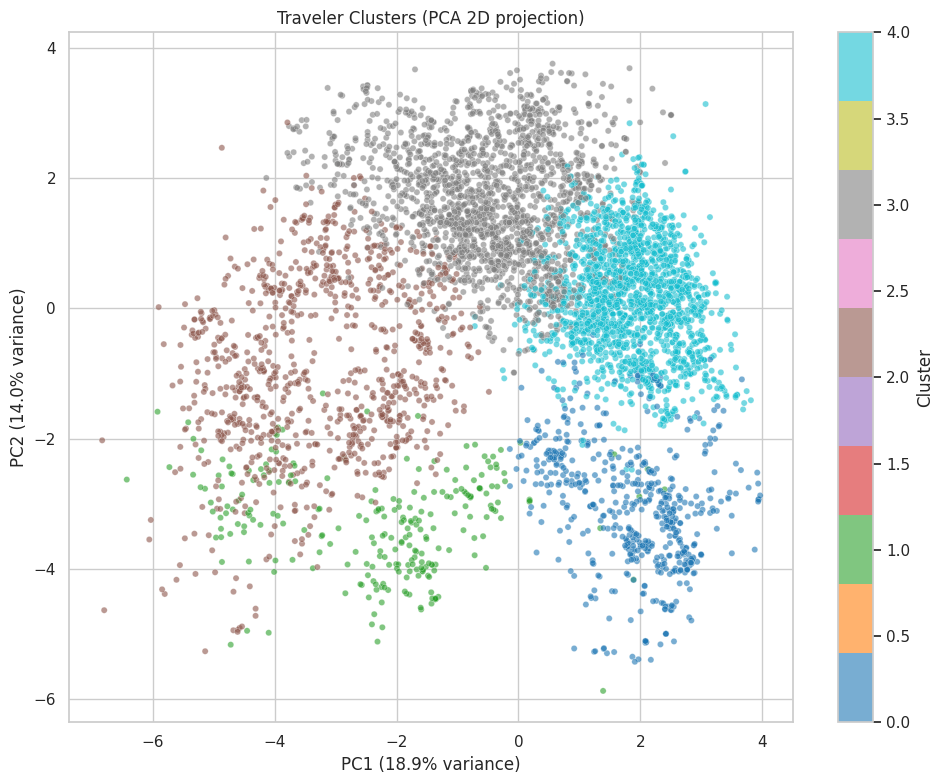

In [35]:
# Visualize clusters (PCA 2D)
from sklearn.decomposition import PCA

if 'cluster' in df_ratings.columns:
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10',
                          alpha=0.6, s=20, edgecolors='white', linewidth=0.3)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax.set_title('Traveler Clusters (PCA 2D projection)')
    plt.colorbar(scatter, label='Cluster')
    plt.tight_layout()
    plt.savefig('data/processed/user_clusters_pca.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 5. Summary of Processed Data

In [36]:
print('=' * 70)
print('TONG KET DU LIEU DA XU LY')
print('=' * 70)

# Kiem tra cleaned files
print('\n--- Cleaned Data ---')
for root, dirs, files in os.walk(CLEANED_DIR):
    for f in sorted(files):
        fpath = os.path.join(root, f)
        size_mb = os.path.getsize(fpath) / (1024*1024)
        if f.endswith('.csv'):
            nrows = sum(1 for _ in open(fpath)) - 1
            print(f'  {f:40s} {size_mb:8.2f} MB   {nrows:>10,} rows')
        else:
            print(f'  {f:40s} {size_mb:8.2f} MB')

# Kiem tra feature files
print('\n--- Feature Files ---')
for root, dirs, files in os.walk(FEATURES_DIR):
    for f in sorted(files):
        fpath = os.path.join(root, f)
        size_mb = os.path.getsize(fpath) / (1024*1024)
        if f.endswith('.npy'):
            arr = np.load(fpath)
            print(f'  {f:40s} {size_mb:8.2f} MB   shape: {arr.shape}')
        elif f.endswith('.npz'):
            print(f'  {f:40s} {size_mb:8.2f} MB   (sparse matrix)')
        else:
            print(f'  {f:40s} {size_mb:8.2f} MB')

# Kiem tra processed images
print('\n--- EDA Plots ---')
for root, dirs, files in os.walk(PROCESSED_DIR):
    for f in sorted(files):
        if f.endswith('.png'):
            fpath = os.path.join(root, f)
            size_kb = os.path.getsize(fpath) / 1024
            print(f'  {f:40s} {size_kb:8.1f} KB')

print('\n' + '=' * 70)
print('HOAN TAT QUY TRINH XU LY DU LIEU')
print('=' * 70)

TONG KET DU LIEU DA XU LY

--- Cleaned Data ---
  .gitkeep                                     0.00 MB
  hotel_reviews.csv                          333.99 MB      515,738 rows
  travel_ratings.csv                           0.91 MB        5,456 rows
  travel_ratings_clustered.csv                 0.92 MB        5,456 rows
  traveler_trips.csv                           0.46 MB          560 rows
  vietnam_weather.csv                         13.60 MB      181,960 rows
  world_cities.csv                             0.46 MB          560 rows

--- Feature Files ---
  .gitkeep                                     0.00 MB
  cost_matrix.npy                              0.01 MB   shape: (30, 30)
  distance_matrix.npy                          0.01 MB   shape: (30, 30)
  review_labels.npy                            0.38 MB   shape: (50000,)
  review_scores.npy                            0.38 MB   shape: (50000,)
  review_tfidf.npz                             8.52 MB   (sparse matrix)
  tfidf_features

---
## Data Mapping → AI Components

| Feature File | AI Component | Description |
|---|---|---|
| `distance_matrix.npy` | **(A) A* Search** | Distance matrix for 30 Vietnam tourist spots |
| `cost_matrix.npy` | **(A) Search** + **(B) CSP** | Travel cost matrix (VND) |
| `travel_time_matrix.npy` | **(A) Search** + **(B) CSP** | Travel time matrix (hours) |
| `vn_tourist_places.csv` | **(A)(B)** | Place info (opening hours, entry fee, category) |
| `vietnam_weather.csv` | **(C) IF-THEN** + **(D) Bayes** | Weather data - 181K rows |
| `weather_probabilities.csv` | **(D) Bayesian Network** | P(rain\|province,month), P(outdoor\|...) |
| `traveler_trips.csv` | **(B) CSP** | Budget, time, and activity type constraints |
| `review_tfidf.npz` | **(E) ML** | TF-IDF vectors for 50K reviews |
| `review_labels.npy` | **(E) ML** | Sentiment labels (binary) |
| `user_features.npy` | **(E) ML** | Feature vectors - 5,456 users × 24 categories |
| `user_cluster_labels.npy` | **(E) ML** | Cluster labels (5 traveler groups) |